# 01 · Tiny Shakespeare baseline

目标：验证 `数据 → GPT forward → loss → backward → optimizer → checkpoint → sampling` 完整链路。

说明：本 notebook **自包含**模型与训练代码，不依赖把 `.py` 写到磁盘；唯一外部文件是公开语料 `tinyshakespeare.txt`。

实验顺序：

1. 确认 Colab GPU 与工作目录。
2. 定义数据 / 模型 / 训练代码，下载语料。
3. 在固定 batch 上过拟合，排除训练链路错误。
4. 运行 baseline 并观察 train/val loss。
5. 使用固定 prompt 采样。
6. 重新加载 checkpoint，确认产物可恢复。

In [1]:
import json
import math
import os
import platform

import random
import subprocess
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

print('python:', platform.python_version())
print('torch:', torch.__version__)
print('cwd:', Path.cwd())
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))
    subprocess.run(['nvidia-smi'], check=False)

python: 3.12.13
torch: 2.11.0+cu128
cwd: /content
cuda available: True
gpu: NVIDIA A100-SXM4-40GB


In [2]:
# 只用于放语料 / checkpoint / 指标；代码都在本 notebook 的 cells 里
if Path('/content').exists():
    STAGE_DIR = Path('/content/03-nanogpt')
else:
    here = Path.cwd().resolve()
    STAGE_DIR = here if here.name == '03-nanogpt' else here.parent if (here.parent / 'model.py').exists() else here / '03-nanogpt'

STAGE_DIR.mkdir(parents=True, exist_ok=True)
(STAGE_DIR / 'data').mkdir(exist_ok=True)
(STAGE_DIR / 'runs').mkdir(exist_ok=True)
(STAGE_DIR / 'configs').mkdir(exist_ok=True)
os.chdir(STAGE_DIR)
print('stage dir:', STAGE_DIR)

stage dir: /content/03-nanogpt


## 数据工具

字符级 tokenizer；输入 `x` 与目标 `y` 相差一个字符。

In [3]:
from dataclasses import dataclass
from pathlib import Path
from urllib.request import urlopen

import torch


TINY_SHAKESPEARE_URL = (
    "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
)


@dataclass(frozen=True)
class CharTokenizer:
    chars: tuple[str, ...]

    @classmethod
    def from_text(cls, text: str) -> "CharTokenizer":
        if not text:
            raise ValueError("cannot build a tokenizer from empty text")
        return cls(tuple(sorted(set(text))))

    @property
    def vocab_size(self) -> int:
        return len(self.chars)

    def encode(self, text: str) -> list[int]:
        stoi = {char: index for index, char in enumerate(self.chars)}
        try:
            return [stoi[char] for char in text]
        except KeyError as error:
            raise ValueError(f"unknown character: {error.args[0]!r}") from error

    def decode(self, token_ids: list[int]) -> str:
        try:
            return "".join(self.chars[token_id] for token_id in token_ids)
        except IndexError as error:
            raise ValueError("token id is outside the tokenizer vocabulary") from error


@dataclass(frozen=True)
class TextData:
    train: torch.Tensor
    val: torch.Tensor
    tokenizer: CharTokenizer


def download_tiny_shakespeare(destination: Path) -> Path:
    """Download the small public corpus once and return its local path."""
    destination = Path(destination)
    if destination.exists():
        return destination

    destination.parent.mkdir(parents=True, exist_ok=True)
    with urlopen(TINY_SHAKESPEARE_URL, timeout=30) as response:
        destination.write_bytes(response.read())
    return destination


def load_text_data(path: Path, train_fraction: float = 0.9) -> TextData:
    if not 0.0 < train_fraction < 1.0:
        raise ValueError("train_fraction must be between 0 and 1")

    text = Path(path).read_text(encoding="utf-8")
    tokenizer = CharTokenizer.from_text(text)
    encoded = torch.tensor(tokenizer.encode(text), dtype=torch.long)
    split_index = int(len(encoded) * train_fraction)
    if split_index < 2 or len(encoded) - split_index < 2:
        raise ValueError("text is too short for a train/validation split")
    return TextData(encoded[:split_index], encoded[split_index:], tokenizer)


def get_batch(
    tokens: torch.Tensor,
    *,
    batch_size: int,
    block_size: int,
    device: torch.device,
    generator: torch.Generator | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    if len(tokens) <= block_size:
        raise ValueError("token sequence must be longer than block_size")

    starts = torch.randint(len(tokens) - block_size, (batch_size,), generator=generator)
    x = torch.stack([tokens[start : start + block_size] for start in starts])
    y = torch.stack([tokens[start + 1 : start + block_size + 1] for start in starts])
    return x.to(device), y.to(device)

## 模型

最小 GPT：causal self-attention、MLP、Transformer block、generate。

In [4]:
import math
from dataclasses import asdict, dataclass

import torch
from torch import nn
from torch.nn import functional as F


@dataclass(frozen=True)
class GPTConfig:
    vocab_size: int
    block_size: int = 128
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 128
    dropout: float = 0.0
    bias: bool = True

    def __post_init__(self) -> None:
        if self.n_embd % self.n_head != 0:
            raise ValueError("n_embd must be divisible by n_head")
        if min(self.vocab_size, self.block_size, self.n_layer, self.n_head, self.n_embd) <= 0:
            raise ValueError("model dimensions must be positive")

    def to_dict(self) -> dict[str, int | float | bool]:
        return asdict(self)


class CausalSelfAttention(nn.Module):
    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(config.block_size, config.block_size, dtype=torch.bool)).view(
                1, 1, config.block_size, config.block_size
            ),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, channels = x.shape
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        head_size = channels // self.n_head
        q = q.view(batch_size, sequence_length, self.n_head, head_size).transpose(1, 2)
        k = k.view(batch_size, sequence_length, self.n_head, head_size).transpose(1, 2)
        v = v.view(batch_size, sequence_length, self.n_head, head_size).transpose(1, 2)

        attention = (q @ k.transpose(-2, -1)) / math.sqrt(head_size)
        attention = attention.masked_fill(
            ~self.causal_mask[:, :, :sequence_length, :sequence_length], float("-inf")
        )
        attention = F.softmax(attention, dim=-1)
        attention = F.dropout(attention, p=self.dropout, training=self.training)
        y = attention @ v
        y = y.transpose(1, 2).contiguous().view(batch_size, sequence_length, channels)
        return self.resid_dropout(self.c_proj(y))


class MLP(nn.Module):
    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))


class Block(nn.Module):
    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MLP(config)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln_1(x))
        return x + self.mlp(self.ln_2(x))


class GPT(nn.Module):
    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(
            {
                "wte": nn.Embedding(config.vocab_size, config.n_embd),
                "wpe": nn.Embedding(config.block_size, config.n_embd),
                "drop": nn.Dropout(config.dropout),
                "h": nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                "ln_f": nn.LayerNorm(config.n_embd, bias=config.bias),
            }
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight
        self.apply(self._init_weights)
        for name, parameter in self.named_parameters():
            if name.endswith("c_proj.weight"):
                nn.init.normal_(parameter, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def num_parameters(self) -> int:
        return sum(parameter.numel() for parameter in self.parameters())

    def forward(
        self, idx: torch.Tensor, targets: torch.Tensor | None = None
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        _, sequence_length = idx.shape
        if sequence_length > self.config.block_size:
            raise ValueError(
                f"sequence length {sequence_length} exceeds block_size {self.config.block_size}"
            )

        positions = torch.arange(sequence_length, device=idx.device)
        x = self.transformer.drop(self.transformer.wte(idx) + self.transformer.wpe(positions))
        for block in self.transformer.h:
            x = block(x)
        logits = self.lm_head(self.transformer.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        idx: torch.Tensor,
        max_new_tokens: int,
        *,
        temperature: float = 1.0,
        top_k: int | None = None,
    ) -> torch.Tensor:
        if temperature <= 0:
            raise ValueError("temperature must be positive")
        if top_k is not None and top_k <= 0:
            raise ValueError("top_k must be positive when provided")
        for _ in range(max_new_tokens):
            idx_context = idx[:, -self.config.block_size :]
            logits, _ = self(idx_context)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                k = min(top_k, logits.size(-1))
                threshold = torch.topk(logits, k).values[:, [-1]]
                logits = logits.masked_fill(logits < threshold, float("-inf"))
            probabilities = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probabilities, num_samples=1)
            idx = torch.cat((idx, next_token), dim=1)
        return idx

## 训练循环

In [5]:
import json
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import numpy as np
import torch



@dataclass(frozen=True)
class TrainConfig:
    data_path: str = "data/tinyshakespeare.txt"
    run_dir: str = "runs/baseline"
    seed: int = 42
    batch_size: int = 32
    block_size: int = 128
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 128
    dropout: float = 0.0
    learning_rate: float = 3e-4
    max_iters: int = 2_000
    eval_interval: int = 200
    eval_iters: int = 50
    log_interval: int = 20
    device: str = "auto"


def resolve_device(requested: str) -> torch.device:
    if requested != "auto":
        return torch.device(requested)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)


def synchronize(device: torch.device) -> None:
    if device.type == "cuda":
        torch.cuda.synchronize(device)


@torch.no_grad()
def estimate_loss(
    model: GPT,
    data: TextData,
    config: TrainConfig,
    device: torch.device,
) -> dict[str, float]:
    model.eval()
    result: dict[str, float] = {}
    eval_generator = torch.Generator().manual_seed(config.seed + 1)
    for split, tokens in (("train", data.train), ("val", data.val)):
        losses = torch.zeros(config.eval_iters)
        for step in range(config.eval_iters):
            x, y = get_batch(
                tokens,
                batch_size=config.batch_size,
                block_size=config.block_size,
                device=device,
                generator=eval_generator,
            )
            _, loss = model(x, y)
            assert loss is not None
            losses[step] = loss.detach().cpu()
        result[split] = losses.mean().item()
    model.train()
    return result


def save_checkpoint(
    path: Path,
    model: GPT,
    optimizer: torch.optim.Optimizer,
    config: TrainConfig,
    tokenizer_chars: tuple[str, ...],
    step: int,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "train_config": asdict(config),
            "model_config": model.config.to_dict(),
            "tokenizer_chars": tokenizer_chars,
            "step": step,
        },
        path,
    )


def load_checkpoint(
    path: Path, device: torch.device
) -> tuple[GPT, dict[str, Any], torch.optim.Optimizer]:
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    model = GPT(GPTConfig(**checkpoint["model_config"])).to(device)
    model.load_state_dict(checkpoint["model"])
    train_config = TrainConfig(**checkpoint["train_config"])
    optimizer = torch.optim.AdamW(model.parameters(), lr=train_config.learning_rate)
    optimizer.load_state_dict(checkpoint["optimizer"])
    return model, checkpoint, optimizer


def run_experiment(config: TrainConfig) -> dict[str, Any]:
    set_seed(config.seed)
    device = resolve_device(config.device)
    data_path = Path(config.data_path)
    download_tiny_shakespeare(data_path)
    data = load_text_data(data_path)

    model_config = GPTConfig(
        vocab_size=data.tokenizer.vocab_size,
        block_size=config.block_size,
        n_layer=config.n_layer,
        n_head=config.n_head,
        n_embd=config.n_embd,
        dropout=config.dropout,
    )
    model = GPT(model_config).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)
    run_dir = Path(config.run_dir)
    run_dir.mkdir(parents=True, exist_ok=True)
    history: list[dict[str, float | int]] = []
    started_at = time.perf_counter()
    training_seconds = 0.0
    train_generator = torch.Generator().manual_seed(config.seed)

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)

    print(f"device={device} parameters={model.num_parameters():,}")
    model.train()
    for step in range(config.max_iters + 1):
        if step % config.eval_interval == 0 or step == config.max_iters:
            losses = estimate_loss(model, data, config, device)
            elapsed = time.perf_counter() - started_at
            record: dict[str, float | int] = {
                "step": step,
                "train_loss": losses["train"],
                "val_loss": losses["val"],
                "elapsed_seconds": elapsed,
                "tokens_per_second": (
                    step * config.batch_size * config.block_size / training_seconds
                    if training_seconds > 0
                    else 0.0
                ),
            }
            history.append(record)
            print(
                f"step={step:5d} train={losses['train']:.4f} "
                f"val={losses['val']:.4f} elapsed={elapsed:.1f}s"
            )
        if step == config.max_iters:
            break

        x, y = get_batch(
            data.train,
            batch_size=config.batch_size,
            block_size=config.block_size,
            device=device,
            generator=train_generator,
        )
        synchronize(device)
        train_step_started_at = time.perf_counter()
        _, loss = model(x, y)
        assert loss is not None
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        synchronize(device)
        training_seconds += time.perf_counter() - train_step_started_at
        if step % config.log_interval == 0:
            print(f"train step={step:5d} batch_loss={loss.item():.4f}")

    checkpoint_path = run_dir / "checkpoint.pt"
    save_checkpoint(
        checkpoint_path,
        model,
        optimizer,
        config,
        data.tokenizer.chars,
        config.max_iters,
    )
    metrics = {
        "config": asdict(config),
        "model_config": model_config.to_dict(),
        "parameters": model.num_parameters(),
        "device": str(device),
        "training_tokens": config.max_iters * config.batch_size * config.block_size,
        "training_seconds": training_seconds,
        "tokens_per_second": (
            config.max_iters * config.batch_size * config.block_size / training_seconds
            if training_seconds > 0
            else 0.0
        ),
        "max_gpu_memory_mb": (
            torch.cuda.max_memory_allocated(device) / (1024**2) if device.type == "cuda" else None
        ),
        "history": history,
        "checkpoint": str(checkpoint_path),
    }
    (run_dir / "metrics.json").write_text(
        json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8"
    )
    return {**metrics, "model": model, "data": data}

## 加载语料

语料下载到 `data/tinyshakespeare.txt`（公开 URL，与私有仓库无关）。

In [6]:
data_path = download_tiny_shakespeare(STAGE_DIR / 'data' / 'tinyshakespeare.txt')
text_data = load_text_data(data_path)
device = resolve_device('auto')
print('device:', device)
print('vocab size:', text_data.tokenizer.vocab_size)
print('train tokens:', len(text_data.train), 'val tokens:', len(text_data.val))
print('characters:', ''.join(text_data.tokenizer.chars))

device: cuda
vocab size: 65
train tokens: 1003854 val tokens: 111540
characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


## 诊断：固定 batch 过拟合

预测：如果模型、loss 和反向传播链路正确，重复训练同一个小 batch 时 loss 应快速下降。这个实验不衡量泛化。

loss: 4.2077 → 0.0104


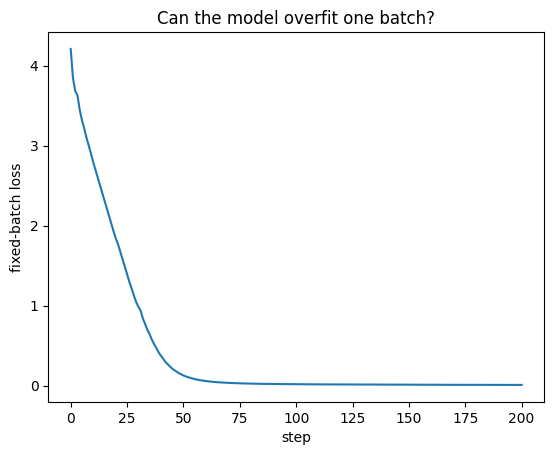

In [7]:
set_seed(42)
diagnostic_config = GPTConfig(
    vocab_size=text_data.tokenizer.vocab_size,
    block_size=32,
    n_layer=2,
    n_head=2,
    n_embd=64,
)
diagnostic_model = GPT(diagnostic_config).to(device)
optimizer = torch.optim.AdamW(diagnostic_model.parameters(), lr=3e-3)
x_fixed, y_fixed = get_batch(
    text_data.train, batch_size=8, block_size=32, device=device
)
diagnostic_losses = []
for step in range(201):
    _, loss = diagnostic_model(x_fixed, y_fixed)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    diagnostic_losses.append(loss.item())

print(f'loss: {diagnostic_losses[0]:.4f} → {diagnostic_losses[-1]:.4f}')
plt.plot(diagnostic_losses)
plt.xlabel('step')
plt.ylabel('fixed-batch loss')
plt.title('Can the model overfit one batch?')
plt.show()

## Baseline

第一次先不调参。运行前记录预测：train loss 与 val loss 会同时下降；后期 train loss 通常下降得更快。

如需把 checkpoint 放到持久目录，可在运行前设置环境变量 `NANOGPT_RUN_DIR`。

In [8]:
baseline_config = TrainConfig(
    data_path=str(STAGE_DIR / 'data' / 'tinyshakespeare.txt'),
    run_dir=os.environ.get('NANOGPT_RUN_DIR', str(STAGE_DIR / 'runs' / 'baseline')),
    seed=42,
    batch_size=32,
    block_size=128,
    n_layer=4,
    n_head=4,
    n_embd=128,
    dropout=0.0,
    learning_rate=3e-4,
    max_iters=2000,
    eval_interval=200,
    eval_iters=50,
    log_interval=20,
    device='auto',
)
baseline_config

TrainConfig(data_path='/content/03-nanogpt/data/tinyshakespeare.txt', run_dir='/content/03-nanogpt/runs/baseline', seed=42, batch_size=32, block_size=128, n_layer=4, n_head=4, n_embd=128, dropout=0.0, learning_rate=0.0003, max_iters=2000, eval_interval=200, eval_iters=50, log_interval=20, device='auto')

In [9]:
result = run_experiment(baseline_config)

device=cuda parameters=818,048
step=    0 train=4.2003 val=4.1982 elapsed=0.4s
train step=    0 batch_loss=4.1965
train step=   20 batch_loss=3.1830
train step=   40 batch_loss=2.8766
train step=   60 batch_loss=2.7452
train step=   80 batch_loss=2.6277
train step=  100 batch_loss=2.5632
train step=  120 batch_loss=2.5783
train step=  140 batch_loss=2.5350
train step=  160 batch_loss=2.5150
train step=  180 batch_loss=2.5090
step=  200 train=2.4787 val=2.4831 elapsed=3.2s
train step=  200 batch_loss=2.4670
train step=  220 batch_loss=2.4274
train step=  240 batch_loss=2.4124
train step=  260 batch_loss=2.4012
train step=  280 batch_loss=2.3559
train step=  300 batch_loss=2.3855
train step=  320 batch_loss=2.3497
train step=  340 batch_loss=2.3754
train step=  360 batch_loss=2.3294
train step=  380 batch_loss=2.3012
step=  400 train=2.3069 val=2.3175 elapsed=5.9s
train step=  400 batch_loss=2.2541
train step=  420 batch_loss=2.3012
train step=  440 batch_loss=2.2763
train step=  460 bat

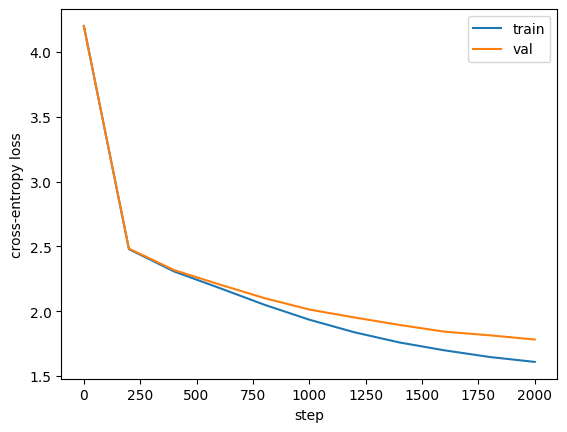

In [10]:
history = result['history']
steps = [row['step'] for row in history]
plt.plot(steps, [row['train_loss'] for row in history], label='train')
plt.plot(steps, [row['val_loss'] for row in history], label='val')
plt.xlabel('step')
plt.ylabel('cross-entropy loss')
plt.legend()
plt.show()

## 固定 prompt 采样

In [13]:
model = result['model']
tokenizer = result['data'].tokenizer
prompt = 'ROMEO:'
prompt_ids = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long, device=device)
set_seed(42)
model.eval()
generated = model.generate(prompt_ids, 1000, temperature=0.8, top_k=20)
print(tokenizer.decode(generated[0].tolist()))

ROMEO:
Fit that that please the me distred he besty:
Auforer me, and be lapinish call have gone
The much I withines ever to againted with
To behind mean to he the hapt me make not dead.


First ORIOLANENCE:
He wilt we as gace thee? worther thee more mine
I have all out to mind the this the milence
To the mind at tongre we bod prisopereingt
Leavy son hearts I haxe god so.

Mettern thee she revolly the paw a amoved bovours,
And death as me honce a can beateds,
I to much make advanse, and whith thine death
This guildess ube he thou man'st a as syrund
To this with all onds not allard.


QUEEN SLIZABETH:
No, I shall I can god and his doubtager
The true the since up, and all leaven's will deept.

Come, all he hast me hath I speech world falsh, not
Fairss is tongue of he ends dine dissue
on licks a purfide myself out are werigue;
But tive he did in his not of not shall more.

AUTOLYCUS:
Have hoter, come it country eyess,
And broth charge have thanks imers.

Stame hold it hence, and water, sir

## Checkpoint 恢复验证

不仅确认文件存在，还重新构造模型与 optimizer，并比较相同输入下的 logits。

In [12]:
checkpoint_path = Path(result['checkpoint'])
restored_model, checkpoint, restored_optimizer = load_checkpoint(checkpoint_path, device)
restored_model.eval()
with torch.no_grad():
    original_logits, _ = model(prompt_ids)
    restored_logits, _ = restored_model(prompt_ids)
torch.testing.assert_close(original_logits, restored_logits)
print('checkpoint restored:', checkpoint_path)
print('saved step:', checkpoint['step'])
print('optimizer state entries:', len(restored_optimizer.state))

checkpoint restored: /content/03-nanogpt/runs/baseline/checkpoint.pt
saved step: 2000
optimizer state entries: 52


## 实验后记录（baseline）

- 固定 batch loss 是否明显下降？
- baseline 的最低 val loss 是多少？
- train/val gap 从什么时候出现？
- 生成文本先学会了哪些结构？
- GPU 型号、训练时间和最大显存是多少？

下一节开始单变量对照（先改 `block_size`）。

## 对照实验 A：只改 `block_size`

其它全部锁死 baseline：`batch=32, n_layer=4, n_head=4, n_embd=128, lr=3e-4, max_iters=2000, seed=42`。

| block_size | 角色 | 预测（先写再跑） |
|------------|------|------------------|
| 64 | 更短上下文 | val 可能更差；更快/更省显存 |
| 128 | baseline 锚点 | val≈1.78（已跑） |
| 256 | 更长上下文 | val 可能更好；更慢、更吃显存；同 step 看到的字符跨度更大 |

注意：同样 `max_iters` 下，更大 `block_size` 每步看的 token 更多（`B*T`），训练 token 总量也更大——解读时一起看，不要只看 step 数。

In [14]:
from dataclasses import replace


def summarize_run(name: str, run: dict) -> dict:
    history = run["history"]
    best = min(history, key=lambda row: row["val_loss"])
    final = history[-1]
    summary = {
        "name": name,
        "block_size": run["config"]["block_size"],
        "parameters": run["parameters"],
        "final_train": final["train_loss"],
        "final_val": final["val_loss"],
        "best_val": best["val_loss"],
        "best_step": best["step"],
        "elapsed_seconds": final["elapsed_seconds"],
        "tokens_per_second": run["tokens_per_second"],
        "training_tokens": run["training_tokens"],
        "max_gpu_memory_mb": run.get("max_gpu_memory_mb"),
    }
    print(
        f"[{name}] params={summary['parameters']:,} "
        f"final train/val={summary['final_train']:.4f}/{summary['final_val']:.4f} "
        f"best_val={summary['best_val']:.4f}@step{summary['best_step']} "
        f"elapsed={summary['elapsed_seconds']:.1f}s "
        f"tok/s={summary['tokens_per_second']:.0f} "
        f"train_tokens={summary['training_tokens']:,} "
        f"max_mem_mb={summary['max_gpu_memory_mb']}"
    )
    return summary


# 复用已跑完的 baseline；若内核刚重启，先重跑上面的 baseline 格
block_size_runs: dict[int, dict] = {}
if "result" in globals():
    block_size_runs[128] = result
    summarize_run("block_size=128 (baseline)", result)
else:
    print("未找到 result：请先跑完 Baseline 再跑本格，或把 128 也放进下面的循环。")

for block_size in (64, 256):
    cfg = replace(
        baseline_config,
        block_size=block_size,
        run_dir=str(STAGE_DIR / "runs" / f"block_size_{block_size}"),
    )
    print(f"\n=== train block_size={block_size} ===")
    block_size_runs[block_size] = run_experiment(cfg)
    summarize_run(f"block_size={block_size}", block_size_runs[block_size])

block_size_summaries = [
    summarize_run(f"block_size={bs}", block_size_runs[bs])
    for bs in sorted(block_size_runs)
]
block_size_summaries

[block_size=128 (baseline)] params=818,048 final train/val=1.6089/1.7817 best_val=1.7817@step2000 elapsed=27.2s tok/s=394841 train_tokens=8,192,000 max_mem_mb=205.04345703125

=== train block_size=64 ===
device=cuda parameters=809,856
step=    0 train=4.2139 val=4.2132 elapsed=0.4s
train step=    0 batch_loss=4.2155
train step=   20 batch_loss=3.2024
train step=   40 batch_loss=2.9187
train step=   60 batch_loss=2.7159
train step=   80 batch_loss=2.6238
train step=  100 batch_loss=2.5906
train step=  120 batch_loss=2.5551
train step=  140 batch_loss=2.5406
train step=  160 batch_loss=2.4643
train step=  180 batch_loss=2.4523
step=  200 train=2.4543 val=2.4549 elapsed=3.2s
train step=  200 batch_loss=2.5146
train step=  220 batch_loss=2.4451
train step=  240 batch_loss=2.3829
train step=  260 batch_loss=2.3427
train step=  280 batch_loss=2.3674
train step=  300 batch_loss=2.3317
train step=  320 batch_loss=2.4089
train step=  340 batch_loss=2.3187
train step=  360 batch_loss=2.2983
trai

[{'name': 'block_size=64',
  'block_size': 64,
  'parameters': 809856,
  'final_train': 1.6814707517623901,
  'final_val': 1.8329899311065674,
  'best_val': 1.8329899311065674,
  'best_step': 2000,
  'elapsed_seconds': 27.832878932999847,
  'tokens_per_second': 192582.6302154327,
  'training_tokens': 4096000,
  'max_gpu_memory_mb': 127.09228515625},
 {'name': 'block_size=128',
  'block_size': 128,
  'parameters': 818048,
  'final_train': 1.6088972091674805,
  'final_val': 1.781742811203003,
  'best_val': 1.781742811203003,
  'best_step': 2000,
  'elapsed_seconds': 27.23806048000006,
  'tokens_per_second': 394841.26328425325,
  'training_tokens': 8192000,
  'max_gpu_memory_mb': 205.04345703125},
 {'name': 'block_size=256',
  'block_size': 256,
  'parameters': 834432,
  'final_train': 1.5922694206237793,
  'final_val': 1.7493793964385986,
  'best_val': 1.7493793964385986,
  'best_step': 2000,
  'elapsed_seconds': 29.909108854999886,
  'tokens_per_second': 737879.7314127764,
  'training_t

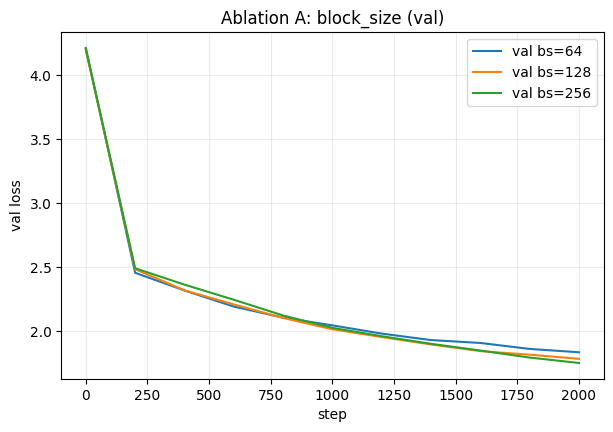


===== sample block_size=64 =====
ROMEO:
Fir that that the worthing doubty.

CLIFO:
Therefore is to--wit, and will so I have good
The must thou sinded it discaured a mon.
Now
MERCUT:
Upon thus that great, my have presed he see with
Thou we subles thou as take thee? what to this make mind
I have a so cation in thee this the man and down:
T

===== sample block_size=128 =====
ROMEO:
Fit that that please the me distred he besty:
Auforer me, and be lapinish call have gone
The much I withines ever to againted with
To behind mean to he the hapt me make not dead.


First ORIOLANENCE:
He wilt we as gace thee? worther thee more mine
I have all out to mind the this the milence
To the 

===== sample block_size=256 =====
ROMEO:
Far that that done good a more this lear,
And the gettle of with lappy shrough burre the
That were cours, be with that conceince.
Nost think mean they last haps me made not should
It winded whoo him subjounce me, what neweedss,
To with the proming thee would of thou hands wh

In [15]:
# val 曲线对比
plt.figure(figsize=(7, 4.5))
for block_size in sorted(block_size_runs):
    history = block_size_runs[block_size]["history"]
    steps = [row["step"] for row in history]
    plt.plot(steps, [row["val_loss"] for row in history], label=f"val bs={block_size}")
plt.xlabel("step")
plt.ylabel("val loss")
plt.title("Ablation A: block_size (val)")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

# 固定 prompt 短采样，方便肉眼比
prompt = "ROMEO:"
device = resolve_device(baseline_config.device)
for block_size in sorted(block_size_runs):
    run = block_size_runs[block_size]
    model = run["model"]
    tokenizer = run["data"].tokenizer
    prompt_ids = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long, device=device)
    set_seed(42)
    model.eval()
    generated = model.generate(prompt_ids, 300, temperature=0.8, top_k=20)
    print(f"\n===== sample block_size={block_size} =====")
    print(tokenizer.decode(generated[0].tolist()))

### 对照 A 读数（已跑）

| block_size | best val | elapsed | max_mem |
|------------|---------:|--------:|--------:|
| 64 | 1.833 | 27.8s | 127 MB |
| 128 | 1.782 | 27.2s | 205 MB |
| 256 | 1.749 | 29.9s | 497 MB |

结论：更长上下文 val 更好；A100 上墙钟差不大，显存差明显。同 step 下训练 token 也更多（混杂因素）。

下一组对照 B：只改 `n_layer`。

## 对照实验 B：只改 `n_layer`

其它锁死 baseline（含 `block_size=128`）。

| n_layer | 角色 | 预测 |
|---------|------|------|
| 2 | 更浅 | val 更差；更快、参数更少 |
| 4 | baseline | val≈1.78 |
| 6 | 更深 | val 可能更好；更慢、更易过拟合 |

In [16]:
n_layer_runs: dict[int, dict] = {}
if "result" in globals():
    n_layer_runs[4] = result
    summarize_run("n_layer=4 (baseline)", result)
else:
    print("未找到 result：请先确保 baseline 在内存中。")

for n_layer in (2, 6):
    cfg = replace(
        baseline_config,
        n_layer=n_layer,
        run_dir=str(STAGE_DIR / "runs" / f"n_layer_{n_layer}"),
    )
    print(f"\n=== train n_layer={n_layer} ===")
    n_layer_runs[n_layer] = run_experiment(cfg)
    summarize_run(f"n_layer={n_layer}", n_layer_runs[n_layer])

n_layer_summaries = [
    summarize_run(f"n_layer={n}", n_layer_runs[n]) for n in sorted(n_layer_runs)
]
n_layer_summaries

[n_layer=4 (baseline)] params=818,048 final train/val=1.6089/1.7817 best_val=1.7817@step2000 elapsed=27.2s tok/s=394841 train_tokens=8,192,000 max_mem_mb=205.04345703125

=== train n_layer=2 ===
device=cuda parameters=421,504
step=    0 train=4.2089 val=4.2037 elapsed=0.3s
train step=    0 batch_loss=4.2023
train step=   20 batch_loss=3.1820
train step=   40 batch_loss=2.8712
train step=   60 batch_loss=2.7480
train step=   80 batch_loss=2.6275
train step=  100 batch_loss=2.5768
train step=  120 batch_loss=2.5942
train step=  140 batch_loss=2.5537
train step=  160 batch_loss=2.5263
train step=  180 batch_loss=2.5362
step=  200 train=2.4937 val=2.4972 elapsed=2.1s
train step=  200 batch_loss=2.4803
train step=  220 batch_loss=2.4692
train step=  240 batch_loss=2.4641
train step=  260 batch_loss=2.4395
train step=  280 batch_loss=2.4102
train step=  300 batch_loss=2.4479
train step=  320 batch_loss=2.4244
train step=  340 batch_loss=2.4479
train step=  360 batch_loss=2.3888
train step=  

[{'name': 'n_layer=2',
  'block_size': 128,
  'parameters': 421504,
  'final_train': 1.7786043882369995,
  'final_val': 1.9161969423294067,
  'best_val': 1.9161969423294067,
  'best_step': 2000,
  'elapsed_seconds': 18.2779212129999,
  'tokens_per_second': 628321.4673277282,
  'training_tokens': 8192000,
  'max_gpu_memory_mb': 152.74267578125},
 {'name': 'n_layer=4',
  'block_size': 128,
  'parameters': 818048,
  'final_train': 1.6088972091674805,
  'final_val': 1.781742811203003,
  'best_val': 1.781742811203003,
  'best_step': 2000,
  'elapsed_seconds': 27.23806048000006,
  'tokens_per_second': 394841.26328425325,
  'training_tokens': 8192000,
  'max_gpu_memory_mb': 205.04345703125},
 {'name': 'n_layer=6',
  'block_size': 128,
  'parameters': 1214592,
  'final_train': 1.5488901138305664,
  'final_val': 1.7341426610946655,
  'best_val': 1.7341426610946655,
  'best_step': 2000,
  'elapsed_seconds': 38.201071019999745,
  'tokens_per_second': 271348.41097708285,
  'training_tokens': 81920

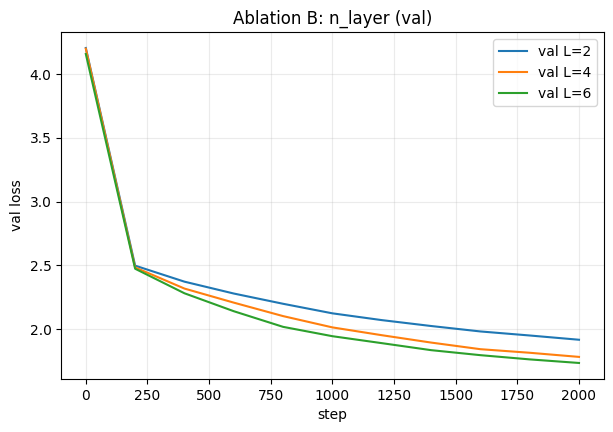


===== sample n_layer=2 =====
ROMEO:

Ound afft my panter the me distring here you.

FLUCESTER:
Now, that will cand but that to well.
GLoody; see with fold, man, more thy
Thou and and that that greattimed, not shairty
Firse is wull him as parice me,
To she meevent to onsuckly and in that well so cast;
Whou have must and his sond werea

===== sample n_layer=4 =====
ROMEO:
Fit that that please the me distred he besty:
Auforer me, and be lapinish call have gone
The much I withines ever to againted with
To behind mean to he the hapt me make not dead.


First ORIOLANENCE:
He wilt we as gace thee? worther thee more mine
I have all out to mind the this the milence
To the 

===== sample n_layer=6 =====
ROMEO:
Fair was that denemy the of distring here:
There's I will a will lap with says have gone
The must take and a sick it a contess in thy
behing mean to my that greate my hands shaest dies:
His wull hich see to poming of she and to tood?

Promment:
And a we lass one to mind the true.

TEdizen

In [17]:
plt.figure(figsize=(7, 4.5))
for n_layer in sorted(n_layer_runs):
    history = n_layer_runs[n_layer]["history"]
    steps = [row["step"] for row in history]
    plt.plot(steps, [row["val_loss"] for row in history], label=f"val L={n_layer}")
plt.xlabel("step")
plt.ylabel("val loss")
plt.title("Ablation B: n_layer (val)")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

prompt = "ROMEO:"
device = resolve_device(baseline_config.device)
for n_layer in sorted(n_layer_runs):
    run = n_layer_runs[n_layer]
    model = run["model"]
    tokenizer = run["data"].tokenizer
    prompt_ids = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long, device=device)
    set_seed(42)
    model.eval()
    generated = model.generate(prompt_ids, 300, temperature=0.8, top_k=20)
    print(f"\n===== sample n_layer={n_layer} =====")
    print(tokenizer.decode(generated[0].tolist()))

### 对照 B 读数（已跑）

| n_layer | best val | elapsed | params |
|---------|---------:|--------:|-------:|
| 2 | 1.916 | 18.3s | 42万 |
| 4 | 1.782 | 27.2s | 82万 |
| 6 | 1.734 | 38.2s | 121万 |

结论：更深 val 更好，时间/参数/显存都更贵。训练 token 相同，归因比 `block_size` 对照更干净。

下一组对照 C：只改 `n_embd`。

## 对照实验 C：只改 `n_embd`

其它锁死 baseline（`n_head=4` 不变，故 `n_embd` 必须能被 4 整除）。

| n_embd | 角色 | 预测 |
|--------|------|------|
| 64 | 更窄 | val 更差；更快、参数更少 |
| 128 | baseline | val≈1.78 |
| 256 | 更宽 | val 可能更好；更慢、参数涨得很快 |

In [18]:
n_embd_runs: dict[int, dict] = {}
if "result" in globals():
    n_embd_runs[128] = result
    summarize_run("n_embd=128 (baseline)", result)
else:
    print("未找到 result：请先确保 baseline 在内存中。")

for n_embd in (64, 256):
    cfg = replace(
        baseline_config,
        n_embd=n_embd,
        run_dir=str(STAGE_DIR / "runs" / f"n_embd_{n_embd}"),
    )
    print(f"\n=== train n_embd={n_embd} ===")
    n_embd_runs[n_embd] = run_experiment(cfg)
    summarize_run(f"n_embd={n_embd}", n_embd_runs[n_embd])

n_embd_summaries = [
    summarize_run(f"n_embd={n}", n_embd_runs[n]) for n in sorted(n_embd_runs)
]
n_embd_summaries

[n_embd=128 (baseline)] params=818,048 final train/val=1.6089/1.7817 best_val=1.7817@step2000 elapsed=27.2s tok/s=394841 train_tokens=8,192,000 max_mem_mb=205.04345703125

=== train n_embd=64 ===
device=cuda parameters=212,416
step=    0 train=4.1747 val=4.1718 elapsed=0.4s
train step=    0 batch_loss=4.1705
train step=   20 batch_loss=3.6378
train step=   40 batch_loss=3.3559
train step=   60 batch_loss=3.1786
train step=   80 batch_loss=2.9999
train step=  100 batch_loss=2.8795
train step=  120 batch_loss=2.8559
train step=  140 batch_loss=2.7851
train step=  160 batch_loss=2.7511
train step=  180 batch_loss=2.7078
step=  200 train=2.6621 val=2.6657 elapsed=3.1s
train step=  200 batch_loss=2.6432
train step=  220 batch_loss=2.6117
train step=  240 batch_loss=2.6006
train step=  260 batch_loss=2.5728
train step=  280 batch_loss=2.5547
train step=  300 batch_loss=2.5754
train step=  320 batch_loss=2.5636
train step=  340 batch_loss=2.5606
train step=  360 batch_loss=2.5242
train step= 

[{'name': 'n_embd=64',
  'block_size': 128,
  'parameters': 212416,
  'final_train': 1.9680405855178833,
  'final_val': 2.0355238914489746,
  'best_val': 2.0355238914489746,
  'best_step': 2000,
  'elapsed_seconds': 27.93644607899978,
  'tokens_per_second': 384091.07535778277,
  'training_tokens': 8192000,
  'max_gpu_memory_mb': 177.29443359375},
 {'name': 'n_embd=128',
  'block_size': 128,
  'parameters': 818048,
  'final_train': 1.6088972091674805,
  'final_val': 1.781742811203003,
  'best_val': 1.781742811203003,
  'best_step': 2000,
  'elapsed_seconds': 27.23806048000006,
  'tokens_per_second': 394841.26328425325,
  'training_tokens': 8192000,
  'max_gpu_memory_mb': 205.04345703125},
 {'name': 'n_embd=256',
  'block_size': 128,
  'parameters': 3208960,
  'final_train': 1.4081312417984009,
  'final_val': 1.624302864074707,
  'best_val': 1.624302864074707,
  'best_step': 2000,
  'elapsed_seconds': 28.351229003999833,
  'tokens_per_second': 385239.9318842742,
  'training_tokens': 8192

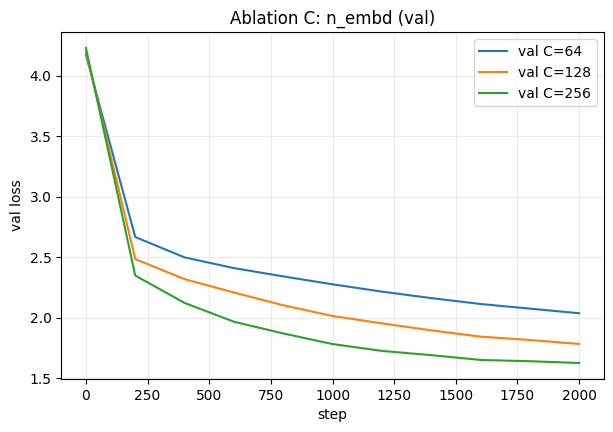


===== sample n_embd=64 =====
ROMEO:
Fit as for and the good a modest not herer con,
Of I f make will lapforsers we but thim,
The must I of nise dever fold conces with pringht.

TUCESHAMBED MOM:
Thout machan the then do wing, brughth consery,
Whou as gach thee sword ment helm;
Dhere that well so carnt minine hey is there.

ORKING
RYIU

===== sample n_embd=128 =====
ROMEO:
Fit that that please the me distred he besty:
Auforer me, and be lapinish call have gone
The much I withines ever to againted with
To behind mean to he the hapt me make not dead.


First ORIOLANENCE:
He wilt we as gace thee? worther thee more mine
I have all out to mind the this the milence
To the 

===== sample n_embd=256 =====
ROMEO:
Fat thou that done goodly modest not here:
There's I will a will lapinish cannot kill'd,
The must I will, be sir, for the comfort thy
brother's precture hath proudemper.

PHENRY BOLINGBROKE:
Whose canst will we as yet now ever duke that?

MERCUTIO:
New you so your for it deedly here thi

In [19]:
plt.figure(figsize=(7, 4.5))
for n_embd in sorted(n_embd_runs):
    history = n_embd_runs[n_embd]["history"]
    steps = [row["step"] for row in history]
    plt.plot(steps, [row["val_loss"] for row in history], label=f"val C={n_embd}")
plt.xlabel("step")
plt.ylabel("val loss")
plt.title("Ablation C: n_embd (val)")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

prompt = "ROMEO:"
device = resolve_device(baseline_config.device)
for n_embd in sorted(n_embd_runs):
    run = n_embd_runs[n_embd]
    model = run["model"]
    tokenizer = run["data"].tokenizer
    prompt_ids = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long, device=device)
    set_seed(42)
    model.eval()
    generated = model.generate(prompt_ids, 300, temperature=0.8, top_k=20)
    print(f"\n===== sample n_embd={n_embd} =====")
    print(tokenizer.decode(generated[0].tolist()))

### 对照 C 读数（已跑）

| n_embd | best val | params | max_mem |
|--------|---------:|-------:|--------:|
| 64 | 2.036 | 21万 | 177 MB |
| 128 | 1.782 | 82万 | 205 MB |
| 256 | **1.624** | 321万 | 420 MB |

结论：加宽对 val 拉动最大；墙钟差不多，参数量涨得最猛。

三组对照完成。详见 Vault `nanoGPT · Tiny Shakespeare baseline`。

## 加长训：宽模型 `n_embd=256`，`max_iters=5000`

基于对照 C 的最好宽度。预测：

- val 有机会低于 1.62
- 中后段可能出现 train/val gap 拉大（过拟合）
- A100 大约 1–1.5 分钟

看什么：最低 val 出现在第几 step；终点是否已经回升。

In [20]:
wide_long_config = replace(
    baseline_config,
    n_embd=256,
    max_iters=5000,
    eval_interval=250,
    run_dir=str(STAGE_DIR / "runs" / "n_embd_256_iters_5000"),
)
print(wide_long_config)
wide_long_result = run_experiment(wide_long_config)
wide_long_summary = summarize_run("n_embd=256, iters=5000", wide_long_result)
wide_long_summary

TrainConfig(data_path='/content/03-nanogpt/data/tinyshakespeare.txt', run_dir='/content/03-nanogpt/runs/n_embd_256_iters_5000', seed=42, batch_size=32, block_size=128, n_layer=4, n_head=4, n_embd=256, dropout=0.0, learning_rate=0.0003, max_iters=5000, eval_interval=250, eval_iters=50, log_interval=20, device='auto')
device=cuda parameters=3,208,960
step=    0 train=4.2279 val=4.2290 elapsed=0.5s
train step=    0 batch_loss=4.2315
train step=   20 batch_loss=2.7351
train step=   40 batch_loss=2.5878
train step=   60 batch_loss=2.5405
train step=   80 batch_loss=2.4598
train step=  100 batch_loss=2.4455
train step=  120 batch_loss=2.4531
train step=  140 batch_loss=2.3966
train step=  160 batch_loss=2.3587
train step=  180 batch_loss=2.3785
train step=  200 batch_loss=2.3095
train step=  220 batch_loss=2.2771
train step=  240 batch_loss=2.2592
step=  250 train=2.2711 val=2.2890 elapsed=3.8s
train step=  260 batch_loss=2.2654
train step=  280 batch_loss=2.1910
train step=  300 batch_loss=

{'name': 'n_embd=256, iters=5000',
 'block_size': 128,
 'parameters': 3208960,
 'final_train': 1.2024257183074951,
 'final_val': 1.5632734298706055,
 'best_val': 1.5521180629730225,
 'best_step': 3750,
 'elapsed_seconds': 68.04850826200027,
 'tokens_per_second': 384941.0238220388,
 'training_tokens': 20480000,
 'max_gpu_memory_mb': 444.7451171875}

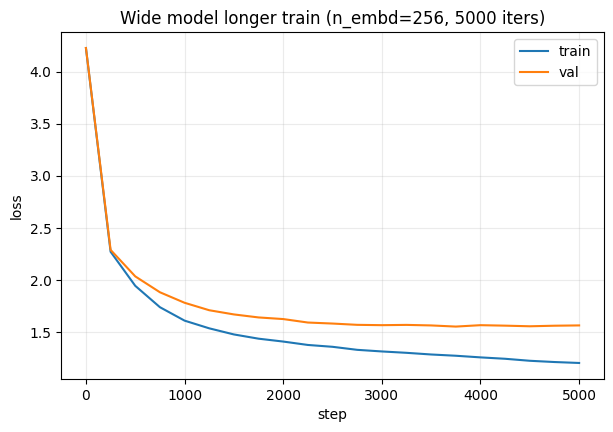

best_val=1.5521@step3750 | final train/val=1.2024/1.5633
ROMEO:
Fat least back me with us, do not so, your consul
In whom a will lapp is but by some other.

PARIS:
That, be not did I contess it thou shalt meant,
Murder than one man, no profit you, no,
That one can be so post, where they?

First Murderer:
Why, that we come to strike thee this name.

FRIAR LAURENCE:
A met least, and speak peace here gone?

Second Servingman:
How is the banish'd mine own fortune


In [21]:
history = wide_long_result["history"]
steps = [row["step"] for row in history]
plt.figure(figsize=(7, 4.5))
plt.plot(steps, [row["train_loss"] for row in history], label="train")
plt.plot(steps, [row["val_loss"] for row in history], label="val")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Wide model longer train (n_embd=256, 5000 iters)")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

best = min(history, key=lambda row: row["val_loss"])
final = history[-1]
print(
    f"best_val={best['val_loss']:.4f}@step{best['step']} | "
    f"final train/val={final['train_loss']:.4f}/{final['val_loss']:.4f}"
)

# 短采样
prompt = "ROMEO:"
device = resolve_device(wide_long_config.device)
model = wide_long_result["model"]
tokenizer = wide_long_result["data"].tokenizer
prompt_ids = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long, device=device)
set_seed(42)
model.eval()
generated = model.generate(prompt_ids, 400, temperature=0.8, top_k=20)
print(tokenizer.decode(generated[0].tolist()))

### 加长训读数（已跑）

- best val = **1.552 @ step 3750**
- final = train 1.202 / val 1.563（终点略差于 best → 轻度过拟合）
- 相对 2000 step 的 1.624：明显提升；再往后性价比下降

结论：宽模型值得多训一会儿，但应保存/使用 val 最好附近，而不是盲目拉满 iters。